## T2

### Import library

In [11]:
import matplotlib.pyplot as plt

### Implementing

In [102]:
class Point:
    def __init__(self, p):
        self.p = p
        self.dim = len(p)
        self.centroid = p

    def distance(self, other) -> float:
        dimension = self.dim
        if dimension != other.dim:
            raise ValueError("Points must have the same dimension") 
        return sum((self.p[i] - other.p[i]) ** 2 for i in range(dimension)) ** 0.5
    
def plot_points_2d(points, colors):
    x = [p.p[0] for p in points]
    y = [p.p[1] for p in points]

    plt.scatter(x, y, color=colors)
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.grid(True)
    
def update_centroid(points) -> list:
    dim = points[0].dim
    num_points = len(points)
    centroid = [0] * dim
    for point in points:
        for i in range(dim):
            centroid[i] += point.p[i]
    for i in range(dim):
        centroid[i] /= num_points
    for p in points:
        p.centroid = centroid
    return centroid

def assign_points_to_centroids(points, centroids):
    clusters = {i: [] for i in range(len(centroids))}
    for point in points:
        distances = [point.distance(centroid) for centroid in centroids]
        closest_centroid_index = distances.index(min(distances))
        clusters[closest_centroid_index].append(point)
    return clusters

def K_Clustering(points, K, initial_centroids, max_iterations=100, plot=True):
    centroids = initial_centroids
    clusters = {i: [centroids[i]] for i in range(K)}
    for iteration in range(max_iterations):

        if plot:
            # Plot current clusters and centroids
            plt.figure()
            for i in range(K):
                cluster_colors = ['C' + str(i)] * len(clusters[i])
                plot_points_2d(clusters[i], cluster_colors)
                plt.scatter(centroids[i].p[0], centroids[i].p[1], color='black', marker='+', s=50)
            plt.title(f'Iteration {iteration + 1}')
            plt.show()

        # Assign points to the nearest centroid
        clusters = assign_points_to_centroids(points, centroids)
        new_centroids = []
        for i in range(K):
            cluster_points = [point.p for point in clusters[i]]
            new_centroid_coords = update_centroid(clusters[i])
            new_centroids.append(Point(new_centroid_coords))

        if all(new_centroids[i].p == centroids[i].p for i in range(K)):
            break
        centroids = new_centroids
    return clusters, centroids

### T5

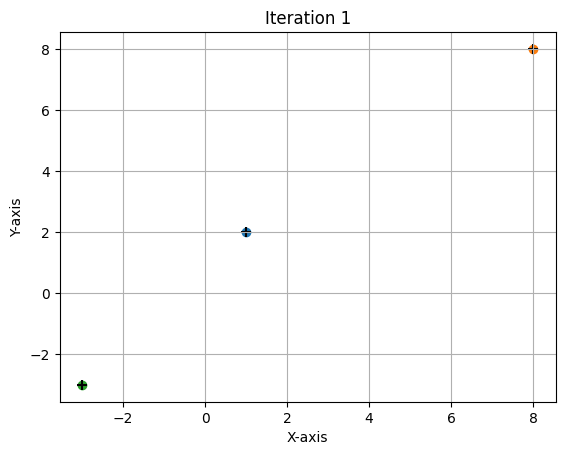

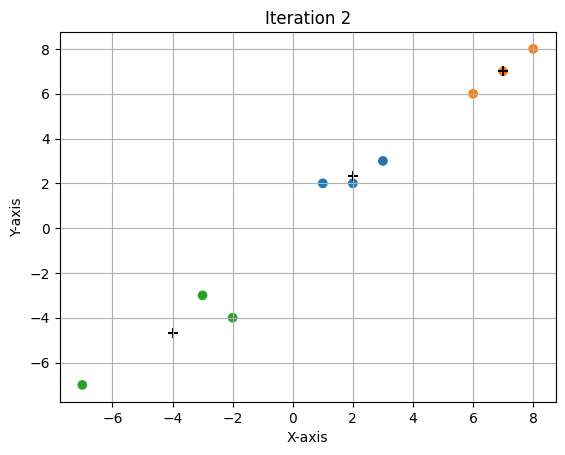

In [98]:
data = [[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]]
points = [Point(p) for p in data]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'black']
K = 3
initial_centroids = [points[0], points[3], points[6]]
K_Clusters, final_centroids = K_Clustering(points, K, initial_centroids)

### T6

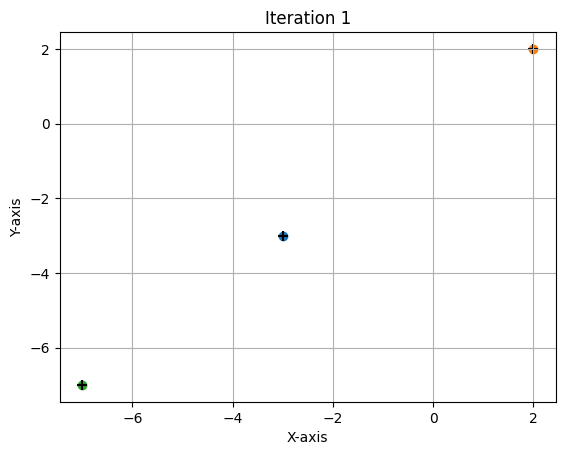

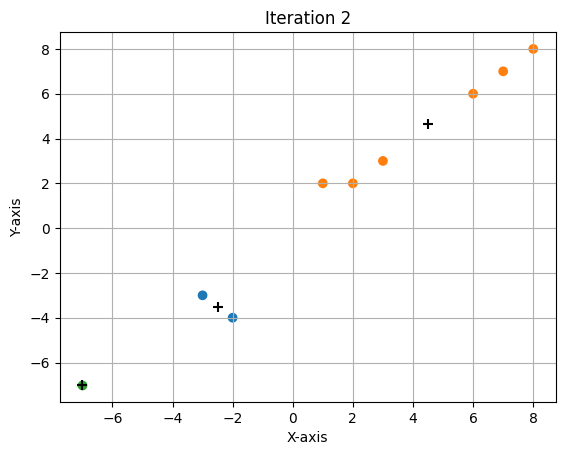

In [96]:
data = [[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]]
points = [Point(p) for p in data]
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'black']
K = 3
initial_centroids = [points[6], points[2], points[8]]
K_Clusters, final_centroids = K_Clustering(points, K, initial_centroids)

### T7

In [161]:
def between_centroids_variance(centroids, cluster, M, K, N) -> float:
    variance = 0
    for i in range(K):
        n = len(cluster[i])
        p = centroids[i]
        distance = p.distance(M)
        variance += n*distance**2/(N - 1)
    return variance

def all_data_variance(points, M) -> float:
    variance = 0
    N = len(points)
    for point in points:
        distance = point.distance(M)
        variance += distance**2/(N - 1)
    return variance

def fraction_of_variance(points, K_Clusters, centroids, K, N, debug=False) -> float:
    between_var = between_centroids_variance(centroids, K_Clusters, Point(update_centroid(points)), K, N)
    all_var = all_data_variance(points, Point(update_centroid(points)))
    if debug:
        print("Between Centroids Variance:", between_var)
        print("All Data Variance:", all_var)
    return between_var / all_var

In [162]:
data = [[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]]
points = [Point(p) for p in data]
K = 3
initial_centroids = [points[0], points[3], points[6]]
K_Clusters, final_centroids = K_Clustering(points, K, initial_centroids, plot=False)
fraction_var = fraction_of_variance(points, K_Clusters, final_centroids, K, len(points), debug=True)
print("Fraction of Variance:", fraction_var)

Between Centroids Variance: 48.611111111111114
All Data Variance: 52.27777777777777
Fraction of Variance: 0.9298618490967058


In [163]:
data = [[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]]
points = [Point(p) for p in data]
K = 3
initial_centroids = [points[6], points[2], points[8]]
K_Clusters, final_centroids = K_Clustering(points, K, initial_centroids, plot=False)
fraction_var = fraction_of_variance(points, K_Clusters, final_centroids, K, len(points), debug=True)
print("Fraction of Variance:", fraction_var)

Between Centroids Variance: 42.548611111111114
All Data Variance: 52.27777777777777
Fraction of Variance: 0.8138947927736452


### OT2

In [164]:
import random

def random_initial_centroids(points, K):
    return random.sample(points, K)

def best_fraction_for_K(points, K, trials=10):
    best_fraction = 0
    best_centroids = None
    best_clusters = None
    for _ in range(trials):
        initial_centroids = random_initial_centroids(points, K)
        K_Clusters, final_centroids = K_Clustering(points, K, initial_centroids, plot=False)
        fraction_var = fraction_of_variance(points, K_Clusters, final_centroids, K, len(points), debug=False)
        if fraction_var > best_fraction:
            best_fraction = fraction_var
            best_centroids = final_centroids
            best_clusters = K_Clusters
    return best_fraction, best_centroids, best_clusters

def elbow_method(points, max_K=10, trials=10):
    fractions = []
    for K in range(1, max_K + 1):
        best_fraction, _, _ = best_fraction_for_K(points, K, trials)
        fractions.append((K, best_fraction))
    return fractions

[(1, 0), (2, 0.7620882040382574), (3, 0.9298618490967058), (4, 0.9816684378320936), (5, 0.9888416578108397), (6, 0.9940223166843785), (7, 0.9964133900106272), (8, 0.9988044633368759), (9, 1.0000000000000002)]


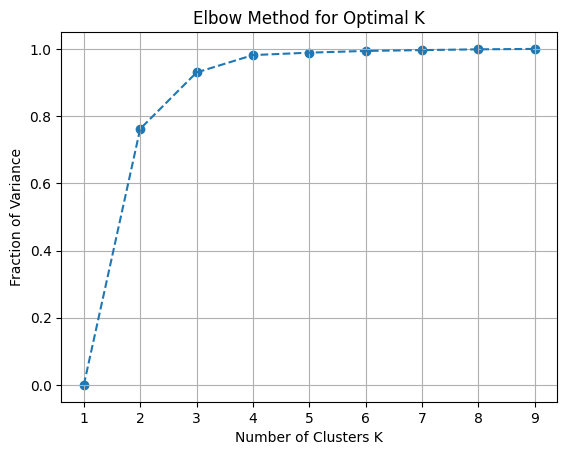

In [168]:
data = [[1, 2], [3, 3], [2, 2], [8, 8], [6, 6], [7, 7], [-3, -3], [-2, -4], [-7, -7]]
points = [Point(p) for p in data]
fractions = elbow_method(points, max_K=9, trials=20)
print(fractions)

plt.figure()
plt.scatter([k for k, f in fractions], [f for k, f in fractions], marker='o')
plt.plot([k for k, f in fractions], [f for k, f in fractions], linestyle='--')
plt.xlabel('Number of Clusters K')
plt.ylabel('Fraction of Variance')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

From the plotting, choosing K with 3 is a best K for the data points which is the minimal K that explains at least 95% of the all-data variance.